# Lab 2（上）財務資料清理與分析：把爬到的髒表格洗乾淨、看懂它

上一個 Lab 你把台積電股價爬成了 `prices.csv`，但那份資料是「髒」的。
今天先把它洗乾淨，再學會用幾行程式看懂一整個月的行情。

In [1]:
# 📦 先跑這一格：指定版本，避免學校電腦裝到不相容的舊版
!pip install -q pandas==2.2.3 numpy==1.26.4 matplotlib==3.10.0


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# 老師的小設定：載入今天整本要用的工具、設好中文字型（直接跑、不用改）
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

# 讓圖上的中文正常顯示（清單第一個是本機認得的字型，其餘是不同系統的備援）
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Noto Sans CJK TC", "Microsoft JhengHei", "PingFang TC", "AR PL UMing CN", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
print("工具載入完成")

工具載入完成


## 🔧 第 0 步：環境檢查

In [3]:
import pandas as pd
import matplotlib
print("pandas    ", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("環境 OK，可以開始")

pandas     2.2.3
matplotlib 3.10.0
環境 OK，可以開始


## A・修 `prices.csv`：上一個 Lab 留下的兩個髒點

上一個 Lab 爬完股價，當場指出兩個地方沒修：日期是民國年、數字帶逗號。今天就修它們。

### A1・照妖鏡：看每一欄到底是什麼型別

> 預期：`日期`、`成交股數`、`收盤價` 等欄位型別全是 `object`（＝文字），不是數字。

In [4]:
df = pd.read_csv("data/prices.csv")   # 💡 讀進上一個 Lab 存的股價（教材附的固定快照，全班同一份）
print(df.dtypes)                        # 💡 dtypes＝一行照妖：長得像數字 ≠ 真的是數字
df.head()                               # 💡 最後一行不用 print，Jupyter 會直接把表格畫出來

日期       object
成交股數     object
成交金額     object
開盤價      object
最高價      object
最低價      object
收盤價      object
漲跌價差     object
成交筆數     object
註記      float64
dtype: object


,日期,成交股數,成交金額,開盤價,最高價,最低價,收盤價,漲跌價差,成交筆數,註記
0,115/06/01,"60,942,792","144,105,259,583","2,355.00","2,415.00","2,350.00","2,355.00",0.00,"136,367",NaN
1,115/06/02,"41,532,527","98,885,005,900","2,390.00","2,400.00","2,360.00","2,380.00",+25.00,"99,496",NaN
2,115/06/03,"29,219,904","70,861,766,012","2,425.00","2,440.00","2,410.00","2,425.00",+45.00,"89,415",NaN
3,115/06/04,"32,542,948","77,931,338,144","2,385.00","2,415.00","2,385.00","2,385.00",-40.00,"196,886",NaN
4,115/06/05,"43,403,895","102,970,368,110","2,395.00","2,405.00","2,350.00","2,365.00",-20.00,"364,351",NaN


### A2・先嚐痛點：叫文字欄算平均會怎樣

> ⚠️ 這一格會**故意報錯**（紅字），這是正常的、預期中的——看完往下走就好。

In [5]:
df["成交股數"].mean()      # 這一欄其實是文字，叫它算平均 → 直接報錯
# 💡 這個錯不是 bug，是 pandas 在保護你：它不猜你想怎麼轉，要你先講清楚

TypeError: Could not convert string '60,942,79241,532,52729,219,90432,542,94843,403,89552,273,85838,847,54454,194,02146,417,52326,306,88530,228,53537,145,70830,059,39349,982,61045,207,88339,537,89567,304,47741,099,95753,800,34438,133,78249,540,227' to numeric

### A3・修第一個髒點：民國日期轉西元

> 預期：印出 `2026-06-01 00:00:00`、型別從 `object` 變成 `datetime64`。

In [6]:
def roc_to_date(s):                       # '115/06/01' → 2026-06-01
    y, m, d = s.split("/")                # 💡 拆成 ['115', '06', '01']
    return pd.Timestamp(int(y) + 1911, int(m), int(d))   # 💡 民國 + 1911 = 西元

df["日期"] = df["日期"].apply(roc_to_date)   # 💡 apply＝對這一欄的每一格套同一個函式
print(df["日期"].iloc[0])
print(df["日期"].dtype)                       # 💡 變成 datetime64 → 之後排序、畫圖才會照時間

2026-06-01 00:00:00
datetime64[ns]


### A4・修第二個髒點：拔逗號 + 轉成數字

> 預期：`成交股數` 變 `int64`、`收盤價` 等變 `float64`。

In [7]:
def to_int(s):                            # '60,942,792' → 60942792
    return int(s.replace(",", ""))        # 💡 先拔逗號、再轉整數——順序反了會報錯

def to_float(s):                          # '2,355.00' → 2355.0
    return float(s.replace(",", ""))

for col in ["成交股數", "成交金額", "成交筆數"]:
    df[col] = df[col].apply(to_int)       # 💡 股數/金額/筆數是整數 → int

for col in ["開盤價", "最高價", "最低價", "收盤價"]:
    df[col] = df[col].apply(to_float)     # 💡 價格有小數 → float

print(df.dtypes)

日期      datetime64[ns]
成交股數             int64
成交金額             int64
開盤價            float64
最高價            float64
最低價            float64
收盤價            float64
漲跌價差            object
成交筆數             int64
註記             float64
dtype: object


### A5・驗收：剛剛報錯的那行，現在算得出來了

> 預期：印出一個平均股數（不再報錯）。

In [8]:
print("這個月平均每天成交股數：", round(df["成交股數"].mean()))
# 💡 同一份資料，洗乾淨之前連平均都算不了——這就是資料清理的價值

這個月平均每天成交股數： 43224891


## B・敘述統計：一行看懂整個月的行情

資料乾淨了，先別急著建模——用幾行程式先「看懂」它。

### B1・一行看懂每一欄：摘要統計

> 預期：一張表，每欄印出筆數/平均/標準差/最小/四分位/最大。

In [9]:
df[["開盤價", "最高價", "最低價", "收盤價"]].describe()   # 💡 describe＝一次給你八個摘要數字
# 💡 最後一行不用 print，Jupyter 直接畫表

,開盤價,最高價,最低價,收盤價
count,21.000000,21.000000,21.000000,21.000000
mean,2369.523810,2396.428571,2350.238095,2371.190476
std,68.809606,67.159193,68.656321,65.075048
min,2230.000000,2260.000000,2210.000000,2250.000000
25%,2330.000000,2370.000000,2325.000000,2340.000000
50%,2375.000000,2400.000000,2350.000000,2380.000000
75%,2410.000000,2420.000000,2390.000000,2400.000000
max,2510.000000,2535.000000,2490.000000,2510.000000


### B2・挑幾個最常看的數字自己算一次

> 預期：印出收盤價的平均、最高、最低、波動。

In [10]:
close = df["收盤價"]                       # 💡 先把收盤價這一欄取出來，等一下重複用
print("平均收盤價：", round(close.mean(), 2))
print("最高：", close.max(), "  最低：", close.min())
print("波動（標準差）：", round(close.std(), 2))   # 💡 標準差＝這個月跳動的劇烈程度

平均收盤價： 2371.19
最高： 2510.0   最低： 2250.0
波動（標準差）： 65.08


## C・畫圖：看圖比看數字快

同樣一份資料，畫成圖，趨勢一眼就看出來。

### C1・收盤價走勢：折線圖

> 預期：一張折線圖，X 軸是日期、Y 軸是收盤價。

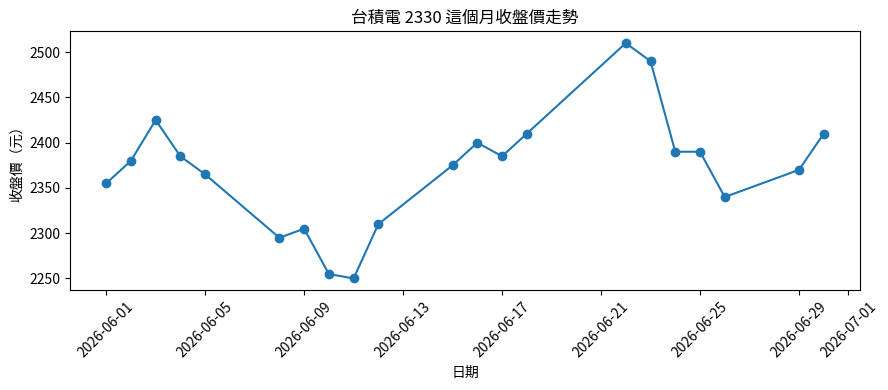

In [11]:
df = df.sort_values("日期")               # 💡 畫圖前先按日期排好，線才不會亂跳

plt.figure(figsize=(9, 4))                # 💡 開一張圖，設定大小
plt.plot(df["日期"], df["收盤價"], marker="o")   # 💡 plot＝折線；marker='o' 每個交易日點一個點
plt.title("台積電 2330 這個月收盤價走勢")
plt.xlabel("日期")
plt.ylabel("收盤價（元）")
plt.xticks(rotation=45)                   # 💡 日期標籤轉 45 度，才不會擠在一起
plt.tight_layout()
plt.show()

### C2・每天成交量：長條圖

> 預期：一張長條圖，看得出哪幾天量特別大。

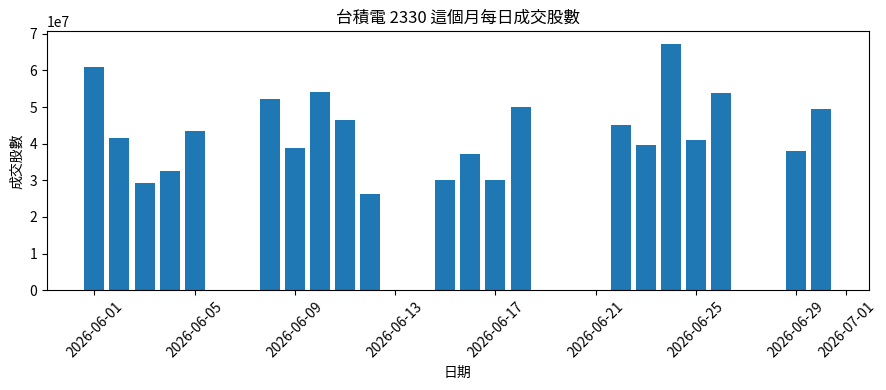

In [12]:
plt.figure(figsize=(9, 4))
plt.bar(df["日期"], df["成交股數"])       # 💡 bar＝長條圖，適合看「每天各多少」
plt.title("台積電 2330 這個月每日成交股數")
plt.xlabel("日期")
plt.ylabel("成交股數")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🔑 這一段你做了什麼

1. 把爬到的髒資料修好（民國轉西元、拔逗號轉數字）
2. 用摘要統計和幾個數字看懂整月行情
3. 把資料畫成折線圖、長條圖

下一段（Lab 2 下）：換一個更方便的資料來源，一行就拿到好幾年的股價。